<a href="https://colab.research.google.com/github/paulAnirban12/Deep-Learning/blob/main/GRU_Text_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import and Setup

In [1]:
# Import PyTorch core modules for model building and training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import re # Import regex for text tokenization

from collections import Counter # Counter is used to count token frequency for vocabulary construction
from datasets import load_dataset

### Load Dataset

In [2]:
dataset = load_dataset("imdb")  # Load the IMDB movie review dataset

train_data = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_split = train_data["train"]
val_split = train_data["test"]
# Split the original training set into training and validation subsets

test_split = dataset["test"]  # Split the original training set into training and validation subsets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Tokenizer

In [3]:
def tokenize(word):
    word = word.lower()
    return re.findall(r"\b\w+\b", word)
# Convert text to lowercase and split into word tokens
# This removes punctuation and keeps only alphanumeric word pieces

### Build Vocabulary

In [4]:
token_counter = Counter()
#Count token frequencies from the training split only, which will be used later to build the vocabulary

for i in range(len(train_split)):
    tokens = tokenize(train_split[i]["text"])
    token_counter.update(tokens)

### Numericalization + Padding

In [5]:
def numericalize(tokens):
    return [vocab.get(t, vocab["<unk>"]) for t in tokens]
# Convert tokens into integer IDs using the vocabulary
# Unknown tokens are mapped to the <unk> token

def pad_sequence(seq, max_len=300):
    seq = seq[:max_len]
    if len(seq) < max_len:
        seq = seq + [vocab["<pad>"]] * (max_len - len(seq))
    return seq
# Pad or truncate each sequence to a fixed length
# This ensures all reviews have the same input size for the GRU model

### Custom Dataset Class

In [6]:
class IMDBDataset(Dataset): #Create a custom PyTorch dataset for IMDB Reviews
    def __init__(self, split):
        self.data = split

    def __len__(self):
        return len(self.data)
    # Return total number of examples in the split

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
    # Convert one review into padded token IDs and return its label

        tokens = tokenize(text) #Tokenize the raw text
        ids = numericalize(tokens)  #Convert tokens into vocabulary IDs
        ids = pad_sequence(ids) #Pad the sequence to fixed length

        return torch.tensor(ids), torch.tensor(label)


train_dataset = IMDBDataset(train_split)
val_dataset = IMDBDataset(val_split)
test_dataset = IMDBDataset(test_split)
# Create dataset objects for training, validation, and testing

### Data Loader

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)
# Create PyTorch DataLoaders for batching and shuffling data
# Training loader uses shuffle=True to improve training randomness

### GRU Model

In [8]:
class GRUModelClassifier(nn.Module): # Define a GRU-based text classification model
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.GRU = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.fclayer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x) # Convert token IDs to embeddings
        out, h = self.GRU(x)  # Pass embeddings through the GRU
        return self.fclayer(h[-1]) #  Use the final hidden state for classification

### Training Setup

In [9]:
min_freq = 5 # Keep tokens that appear more than the minimum frequency threshold

special_tokens = ["<unk>", "<pad>"] # Keep tokens that appear more than the minimum frequency threshold

filtered_tokens = [token for token, count in token_counter.items() if count > min_freq]
vocab = {token: i for i, token in enumerate(special_tokens + filtered_tokens)}
# Build the vocabulary from filtered training tokens

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available, otherwise fall back to CPU

model = GRUModelClassifier(len(vocab), 128, 128).to(device) # Initialize the GRU model

criterion = nn.CrossEntropyLoss() # CrossEntropyLoss is suitable for 2-class classification with logits output

optimizer = optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer is used for training

### Train and Evaluate

In [10]:
def train_epoch(model, loader): # Train the model for one epoch
    model.train()
    total, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device) # Move input batch and labels to the selected device

        optimizer.zero_grad() # Reset gradients from the previous step

        preds = model(x)  # Forward Pass

        loss = criterion(preds, y)  # Compute classification loss

        loss.backward()  # Backward Pass

        optimizer.step()  # Update model parameters

        predicted = preds.argmax(1)  # Convert logits to predicted class index

        correct += (predicted == y).sum().item()
        total += y.size(0)
         # Accumulate correct predictions

    return correct / total

def evaluate(model, loader):  # Evaluate the model without updating weights
    model.eval()
    total, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device) # Move data to the selected device

            preds = model(x)  #Forward pass

            predicted = preds.argmax(1) # Convert logits to predicted class index

            correct += (predicted == y).sum().item()
            total += y.size(0)
            # Accumulate accuracy counts

    return correct / total

for epoch in range(10): # Train the model for multiple epochs and monitor validation accuracy
    train_accuracy = train_epoch(model, train_loader)
    validation_accuracy = evaluate(model, validation_loader)
    test_accuracy = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: Train Acc = {train_accuracy:.4f}, Validation Acc = {validation_accuracy:.4f},  Test Acc = {test_accuracy:.4f}")

Epoch 1: Train Acc = 0.5060, Validation Acc = 0.5104,  Test Acc = 0.5096
Epoch 2: Train Acc = 0.6069, Validation Acc = 0.7068,  Test Acc = 0.6933
Epoch 3: Train Acc = 0.7900, Validation Acc = 0.8398,  Test Acc = 0.8290
Epoch 4: Train Acc = 0.8958, Validation Acc = 0.8718,  Test Acc = 0.8560
Epoch 5: Train Acc = 0.9452, Validation Acc = 0.8666,  Test Acc = 0.8532
Epoch 6: Train Acc = 0.9738, Validation Acc = 0.8662,  Test Acc = 0.8488
Epoch 7: Train Acc = 0.9849, Validation Acc = 0.8618,  Test Acc = 0.8479
Epoch 8: Train Acc = 0.9916, Validation Acc = 0.8652,  Test Acc = 0.8466
Epoch 9: Train Acc = 0.9933, Validation Acc = 0.8692,  Test Acc = 0.8481
Epoch 10: Train Acc = 0.9957, Validation Acc = 0.8554,  Test Acc = 0.8343


## GRU Table

In [11]:
import pandas as pd

# Create a table for GRU parameter details and results
gru_results_df = pd.DataFrame([
    {
        "Experiment": "Experiment 1",
        "Model": "GRU",
        "Dataset": "IMDB",
        "Learning Rate": 0.001,
        "Batch Size": 64,
        "Epochs": 10,
        "Embedding Dim": 128,
        "GRU Units": 64,
        "Max Length": 200,
        "Optimizer": "Adam",
        "Loss Function": "Binary Crossentropy",
        "Best Validation Accuracy": 0.8784,
        "Test Accuracy": 0.8467
    }
])


gru_results_df.to_csv("GRU_Evaluation_Table.csv", index=False)  # Save the table as a CSV file

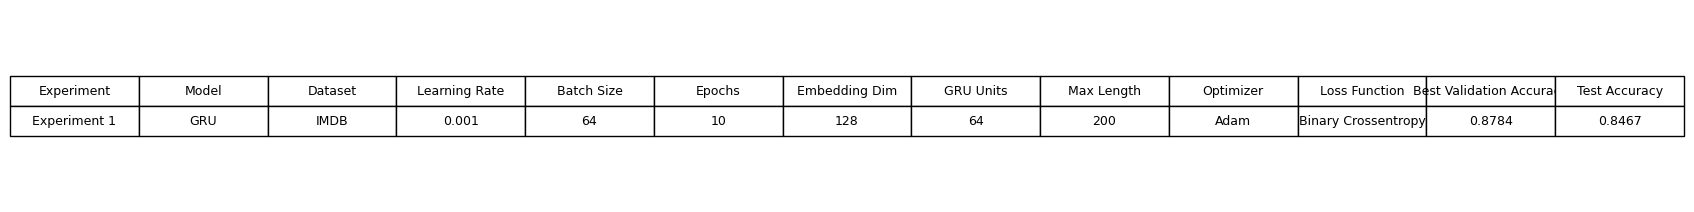

In [12]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(18, 2.5))
ax.axis("off")

# Add table
table = ax.table(
    cellText=gru_results_df.values,
    colLabels=gru_results_df.columns,
    loc="center",
    cellLoc="center"
)

# Adjust font and scaling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Save as PDF
plt.savefig("GRU_Evaluation_Table.jpg", bbox_inches="tight")
plt.show()